# DXA prototype v5.3 — QC-oriented revision

Прототип приведён к структуре конкурсного ТЗ: DICOM → трёхклассовый роутер
`SPINE / LEG_LEFT / LEG_RIGHT` → специализированные проверки → структурированный QC-результат.

**Бедро**

1. три анатомические области и три минимальных поперечных сечения;
2. проверка поля/ROI 3 см сверху, 3 см снизу и 2 см справа по `PixelSpacing`;
3. бинарный CNN-head для металла.

**Позвоночник**

4. угол общей оси относительно вертикали (`≤ 5°`);
5. отдельная проверка покрытия: примерно половина T12 и верхние края обеих подвздошных костей;
6. исследовательский `scoliosis_proxy` сохранён и явно не называется углом Cobb.

Разделение train/validation выполняется на уровне пациента (с fallback на StudyInstanceUID),
чтобы изображения одного пациента не попадали в разные выборки.


## 0. Установка

In [1]:
%pip install -q pydicom pylibjpeg pylibjpeg-libjpeg numpy pandas matplotlib scipy scikit-image scikit-learn pillow tqdm torch torchvision opencv-python-headless openpyxl
# Для SAM при необходимости:
# %pip install -q https://github.com/facebookresearch/segment-anything/archive/refs/heads/main.zip


Note: you may need to restart the kernel to use updated packages.


## 1. Импорты и конфигурация

In [2]:
from pathlib import Path, PurePosixPath
from contextlib import nullcontext
from functools import lru_cache
import math, random, re, time, urllib.request, warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pydicom
from PIL import Image
from scipy.ndimage import gaussian_filter1d, map_coordinates, binary_closing, binary_fill_holes, label as ndi_label
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights

try:
    from pydicom.pixels import apply_modality_lut, apply_voi_lut
except ImportError:
    from pydicom.pixel_data_handlers.util import apply_modality_lut, apply_voi_lut

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path(r"C:\Users\Андрей\Desktop\Хакатон")
STUDIES_ROOT = DATASET_ROOT / "Исследования"
LABELS_CSV = DATASET_ROOT / "Размеченные" / "labels.csv"
TASK_TABLE_CANDIDATES = [DATASET_ROOT / "разметка.xlsx", DATASET_ROOT / "разметка.csv"]
TASK_TABLE_PATH = next((p for p in TASK_TABLE_CANDIDATES if p.exists()), None)
WORK_DIR = DATASET_ROOT / "prototype_output"
WORK_DIR.mkdir(exist_ok=True)

EXPECTED_COUNTS = {"LEG": 333, "SPINE": 166}
BACKGROUND_QUANTILE = 0.01
IMAGE_SIZE, BATCH_SIZE, NUM_WORKERS = 224, 16, 0
HEAD_EPOCHS, FINETUNE_EPOCHS = 3, 5

FIG_SMALL, FIG_WIDE, FIG_TALL = (4, 3), (7, 3.5), (4, 5)

# Три направления поиска минимальной ширины. Названия можно уточнить после экспертной разметки.
HIP_ANGLES = {"1": -30.0, "2": 45.0, "3": -30.0}
HIP_REGION_NAMES = {"1": "большой вертел", "2": "шейка бедра", "3": "седалищная кость"}
HIP_OFFSET_SEARCH_PX, HIP_LINE_HALF_LENGTH_PX = 45, 160
HIP_MIN_NONZERO_PIXELS = 5
HIP_ROI_TOP_MM, HIP_ROI_BOTTOM_MM, HIP_ROI_RIGHT_MM = 30.0, 30.0, 20.0

SPINE_N_VERTEBRAE = 7
SPINE_N_SEPARATORS = SPINE_N_VERTEBRAE - 1
SPINE_BRIGHT_FRACTION = 0.10
SPINE_MIN_SEPARATOR_DISTANCE_DIVISOR = 7
SPINE_SEGMENT_NAMES = ["T12", "L1", "L2", "L3", "L4", "L5", "SACRUM"]
SPINE_MAX_TILT_DEG = 5.0
T12_VISIBLE_FRACTION_RANGE = (0.30, 0.75)
ILIAC_TOP_Y_RANGE = (0.50, 0.90)
ILIAC_AREA_RANGE = (0.003, 0.25)

SAM_MODEL_TYPE = "vit_b"
SAM_CHECKPOINT = DATASET_ROOT / "sam_vit_b_01ec64.pth"
SAM_CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"

print("DEVICE:", DEVICE)
print("DATASET_ROOT:", DATASET_ROOT)


DEVICE: cuda
DATASET_ROOT: C:\Users\Андрей\Desktop\Хакатон


## 2. DICOM, мягкое отсечение фона и финальная разметка

In [3]:
def normalize_relpath(value):
    return str(value or "").strip().replace("\\", "/").lstrip("./")

def rel_to_path(value):
    return Path(*PurePosixPath(normalize_relpath(value)).parts)

def read_dicom_image(path):
    ds = pydicom.dcmread(path, force=True)
    arr = np.asarray(apply_modality_lut(ds.pixel_array, ds), dtype=np.float32)
    try:
        arr = np.asarray(apply_voi_lut(arr, ds), dtype=np.float32)
    except Exception:
        pass
    finite = np.isfinite(arr)
    if not finite.any():
        raise ValueError(f"В DICOM нет конечных значений PixelData: {path}")
    lo, hi = np.nanpercentile(arr[finite], [0.5, 99.5])
    if hi <= lo:
        lo, hi = np.nanmin(arr[finite]), np.nanmax(arr[finite])
    img = np.clip((arr - lo) / max(hi - lo, 1e-6), 0, 1)
    if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
        img = 1 - img
    return ds, img.astype(np.float32)

def threshold_background(img, q=BACKGROUND_QUANTILE):
    positive = img[img > 0]
    if not len(positive):
        return img.copy(), 0.0
    threshold = float(np.quantile(positive, q))
    out = img.copy(); out[out < threshold] = 0
    return out, threshold

def preprocess_dicom(path):
    ds, img = read_dicom_image(path)
    filtered, threshold = threshold_background(img)
    return ds, img, filtered, threshold

def pixel_spacing_mm(ds):
    """Возвращает (row_mm, col_mm); не подменяет отсутствующий spacing фиктивным значением."""
    for name in ("PixelSpacing", "ImagerPixelSpacing", "NominalScannedPixelSpacing"):
        value = getattr(ds, name, None)
        if value is not None and len(value) >= 2:
            try:
                row_mm, col_mm = float(value[0]), float(value[1])
                if row_mm > 0 and col_mm > 0:
                    return row_mm, col_mm
            except (TypeError, ValueError):
                pass
    return None

@lru_cache(maxsize=None)
def dicom_identifiers(path_string):
    path = Path(path_string)
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)
        patient = str(getattr(ds, "PatientID", "")).strip()
        study = str(getattr(ds, "StudyInstanceUID", "")).strip()
        sop = str(getattr(ds, "SOPInstanceUID", "")).strip()
        return patient, study, sop
    except Exception as exc:
        warnings.warn(f"Не удалось прочитать DICOM metadata {path.name}: {exc}")
        return "", "", ""

def load_labels():
    df = pd.read_csv(LABELS_CSV, dtype=str).fillna("")
    df["relative_path"] = df["relative_path"].map(normalize_relpath)
    df["label"] = df["label"].str.strip().str.upper()
    if "side" not in df.columns: df["side"] = ""
    if "metal" not in df.columns: df["metal"] = ""
    df["side"] = df["side"].str.strip().str.upper()
    df["metal"] = df["metal"].astype(str).str.strip()
    df["dicom_path"] = df["relative_path"].map(lambda p: STUDIES_ROOT / rel_to_path(p))

    missing = df[~df["dicom_path"].map(Path.exists)]
    if len(missing):
        raise FileNotFoundError(f"Не найдено {len(missing)} DICOM из labels.csv")

    counts = df["label"].value_counts().to_dict()
    if len(df) != 499 or any(counts.get(k, 0) != v for k, v in EXPECTED_COUNTS.items()):
        raise ValueError(f"Неожиданная разметка: n={len(df)}, counts={counts}")

    df["study_id"] = df["relative_path"].str.split("/").str[0]
    ids = df["dicom_path"].map(lambda p: dicom_identifiers(str(p)))
    df[["patient_id", "study_uid", "sop_uid"]] = pd.DataFrame(ids.tolist(), index=df.index)
    # PatientID — основной group; если его нет, используем UID исследования, затем имя папки.
    df["patient_group"] = df["patient_id"].where(df["patient_id"].ne(""), df["study_uid"])
    df["patient_group"] = df["patient_group"].where(df["patient_group"].ne(""), df["study_id"])

    df["anatomy3"] = np.where(
        df["label"].eq("SPINE"), "SPINE",
        np.where(df["side"].eq("LEFT"), "LEG_LEFT",
                 np.where(df["side"].eq("RIGHT"), "LEG_RIGHT", ""))
    )
    return df

labels_df = load_labels()
display(labels_df["label"].value_counts().rename("count").to_frame())
print("3-class:", labels_df.loc[labels_df["anatomy3"].ne(""), "anatomy3"].value_counts().to_dict())
print("Уникальных patient-level groups:", labels_df["patient_group"].nunique())
print("Металл размечен у ног:", labels_df.loc[labels_df["label"].eq("LEG"), "metal"].isin(["0", "1"]).sum())


C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.08110703091310150605090907130304'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.03030811151201151502050615010000'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.06000812101106141213041404150112'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  w

,count
label,
LEG,333
SPINE,166


3-class: {'SPINE': 166, 'LEG_LEFT': 26, 'LEG_RIGHT': 25}
Уникальных patient-level groups: 1
Металл размечен у ног: 51


### Трёхклассовый роутер и защита от leakage

Основной роутер использует классы `SPINE`, `LEG_LEFT`, `LEG_RIGHT`. Строки ног без `side`
не включаются в его обучение. Train/validation делятся по `PatientID`; при отсутствии
идентификатора пациента используется `StudyInstanceUID`, затем идентификатор папки исследования.
После split код явно проверяет, что группы не пересекаются.


## 3. Компактный ResNet-классификатор и скрытые представления

In [4]:
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

def dicom_to_pil(path):
    _, img, _, _ = preprocess_dicom(path)
    return Image.fromarray((img * 255).astype(np.uint8)).convert("RGB")

class DicomDataset(Dataset):
    def __init__(self, df, class_col, class_to_idx):
        self.df = df.reset_index(drop=True)
        self.class_col, self.class_to_idx = class_col, class_to_idx
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        x = transform(dicom_to_pil(row["dicom_path"]))
        y = torch.tensor(self.class_to_idx[row[self.class_col]], dtype=torch.long)
        return x, y, str(row["dicom_path"])

class BinaryDicomDataset(Dataset):
    def __init__(self, df, target_col):
        self.df, self.target_col = df.reset_index(drop=True), target_col
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        x = transform(dicom_to_pil(row["dicom_path"]))
        y = torch.tensor(float(row[self.target_col]), dtype=torch.float32)
        return x, y, str(row["dicom_path"])

def grouped_train_val_split(df, label_col="label", group_col="patient_group", val_size=0.20):
    """Stratified split without patient/study leakage."""
    work = df.dropna(subset=[label_col, group_col]).copy()
    class_group_counts = work.groupby(label_col)[group_col].nunique()
    requested_splits = max(2, int(round(1 / val_size)))
    n_splits = min(requested_splits, int(class_group_counts.min()))
    if n_splits < 2:
        raise ValueError(f"Недостаточно независимых групп по классам: {class_group_counts.to_dict()}")

    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    best = None
    global_dist = work[label_col].value_counts(normalize=True)
    for train_idx, val_idx in splitter.split(work, work[label_col], groups=work[group_col]):
        train_df, val_df = work.iloc[train_idx].copy(), work.iloc[val_idx].copy()
        if set(train_df[label_col]) != set(work[label_col]) or set(val_df[label_col]) != set(work[label_col]):
            continue
        score = (val_df[label_col].value_counts(normalize=True).reindex(global_dist.index, fill_value=0) - global_dist).abs().sum()
        if best is None or score < best[0]:
            best = (float(score), train_df, val_df)
    if best is None:
        raise ValueError("Не удалось получить fold, содержащий все классы в train и validation.")

    train_df, val_df = best[1], best[2]
    overlap = set(train_df[group_col]) & set(val_df[group_col])
    if overlap:
        raise AssertionError(f"Обнаружен leakage: {len(overlap)} общих групп")
    print(f"TRAIN={len(train_df)}, VAL={len(val_df)}, groups overlap=0")
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

def build_resnet(n_classes, binary=False):
    try:
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    except Exception as exc:
        warnings.warn(f"ImageNet weights недоступны, используется случайная инициализация: {exc}")
        model = resnet18(weights=None)
    for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 1 if binary else n_classes)
    return model.to(DEVICE)

def amp_ctx():
    return torch.amp.autocast(device_type="cuda") if DEVICE.type == "cuda" else nullcontext()

def run_multiclass_epoch(model, loader, loss_fn, optimizer=None):
    train = optimizer is not None
    model.train(train); losses, yt, yp, probs = [], [], [], []
    with torch.set_grad_enabled(train):
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train: optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                logits = model(x); loss = loss_fn(logits, y)
            if train: loss.backward(); optimizer.step()
            p = torch.softmax(logits.detach(), 1)
            losses.append(float(loss.item())); yt.extend(y.cpu().tolist())
            yp.extend(p.argmax(1).cpu().tolist()); probs.extend(p.cpu().numpy())
    metrics = multiclass_classification_metrics(np.asarray(yt), np.asarray(probs))
    return {"loss": float(np.mean(losses)), **metrics}, (np.asarray(yt), np.asarray(yp), np.asarray(probs))

def fit_classifier(train_df, val_df, class_to_idx, class_col="anatomy3", epochs_head=HEAD_EPOCHS, epochs_ft=FINETUNE_EPOCHS):
    """Совместимо с вызовом fit_classifier(train_df, val_df, class_to_idx)."""
    train_loader = DataLoader(DicomDataset(train_df, class_col, class_to_idx), BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(DicomDataset(val_df, class_col, class_to_idx), BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    counts = train_df[class_col].value_counts()
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    weights = torch.tensor([len(train_df)/(len(class_to_idx)*counts[idx_to_class[i]]) for i in range(len(class_to_idx))], dtype=torch.float32, device=DEVICE)
    model, loss_fn, history = build_resnet(len(class_to_idx)), nn.CrossEntropyLoss(weight=weights), []

    opt = torch.optim.AdamW(model.fc.parameters(), lr=1e-3)
    for epoch in range(epochs_head):
        tr, _ = run_multiclass_epoch(model, train_loader, loss_fn, opt)
        va, val_out = run_multiclass_epoch(model, val_loader, loss_fn)
        history.append({"phase":"head", "epoch":epoch+1, **{f"train_{k}":v for k,v in tr.items()}, **{f"val_{k}":v for k,v in va.items()}})

    for p in model.layer4.parameters(): p.requires_grad = True
    opt = torch.optim.AdamW([{"params":model.layer4.parameters(),"lr":1e-4},{"params":model.fc.parameters(),"lr":3e-4}])
    for epoch in range(epochs_ft):
        tr, _ = run_multiclass_epoch(model, train_loader, loss_fn, opt)
        va, val_out = run_multiclass_epoch(model, val_loader, loss_fn)
        history.append({"phase":"finetune", "epoch":epoch+1, **{f"train_{k}":v for k,v in tr.items()}, **{f"val_{k}":v for k,v in va.items()}})
    return model, pd.DataFrame(history), val_out

ANATOMY_CLASS_TO_IDX = {"SPINE": 0, "LEG_LEFT": 1, "LEG_RIGHT": 2}
three_class_df = labels_df[labels_df["anatomy3"].isin(ANATOMY_CLASS_TO_IDX)].copy()

def train_anatomy_router():
    train_df, val_df = grouped_train_val_split(three_class_df, label_col="anatomy3")
    model, history, val_outputs = fit_classifier(train_df, val_df, ANATOMY_CLASS_TO_IDX, class_col="anatomy3")
    torch.save({"state_dict": model.state_dict(), "class_to_idx": ANATOMY_CLASS_TO_IDX}, WORK_DIR / "resnet18_anatomy3.pt")
    return model, history, val_outputs, train_df, val_df

print("Доступно для 3-классового роутера:", three_class_df["anatomy3"].value_counts().to_dict())
print("Для обучения: anatomy_model, history_df, val_outputs, train_df, val_df = train_anatomy_router()")


Доступно для 3-классового роутера: {'SPINE': 166, 'LEG_LEFT': 26, 'LEG_RIGHT': 25}
Для обучения: anatomy_model, history_df, val_outputs, train_df, val_df = train_anatomy_router()


In [5]:
_MODEL_CACHE, _MODEL_LOAD_ERRORS = {}, {}

def load_checkpoint_once(cache_key, checkpoint_path, builder):
    """Одна попытка загрузки на процесс; успешная модель переиспользуется."""
    if cache_key in _MODEL_CACHE:
        return _MODEL_CACHE[cache_key]
    if cache_key in _MODEL_LOAD_ERRORS:
        raise RuntimeError(f"Предыдущая загрузка {cache_key} завершилась ошибкой") from _MODEL_LOAD_ERRORS[cache_key]
    try:
        payload = torch.load(checkpoint_path, map_location=DEVICE)
        model = builder(payload).to(DEVICE).eval()
        model.load_state_dict(payload["state_dict"])
        _MODEL_CACHE[cache_key] = model
        return model
    except Exception as exc:
        _MODEL_LOAD_ERRORS[cache_key] = exc
        raise

@torch.no_grad()
def predict_multiclass(model, path, class_to_idx):
    idx_to_class = {v:k for k,v in class_to_idx.items()}
    x = transform(dicom_to_pil(path)).unsqueeze(0).to(DEVICE)
    prob = torch.softmax(model(x), 1)[0].cpu().numpy()
    idx = int(np.argmax(prob))
    return idx_to_class[idx], float(prob[idx]), prob

def show_classification_examples(model, df, class_col, class_to_idx, n=6):
    sample = df.sample(min(n, len(df)), random_state=SEED)
    fig, axes = plt.subplots(2, 3, figsize=(6, 4))
    for ax in axes.flat: ax.axis("off")
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        pred, confidence, _ = predict_multiclass(model, row["dicom_path"], class_to_idx)
        _, img, _, _ = preprocess_dicom(row["dicom_path"])
        ax.imshow(img, cmap="gray"); ax.set_title(f"{row[class_col]} → {pred}\nP={confidence:.2f}", fontsize=8)
    plt.tight_layout(); plt.show()


## 4. `разметка.csv`: извлечение разметки шести задач

In [6]:
UID_RE = re.compile(r"^(?:2\.25\.\d+|1\.2(?:\.\d+)+)$")

def read_task_raw(path):
    """Читает разметка.xlsx или разметка.csv без фиксированного числа строк заголовка."""
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path, header=None, dtype=str).fillna("")

    last_error = None
    for enc in ("utf-8-sig", "cp1251", "utf-8"):
        try:
            return pd.read_csv(path, header=None, sep=None, engine="python", dtype=str, encoding=enc).fillna("")
        except Exception as e:
            last_error = e
    raise last_error


def load_task_table(path=TASK_TABLE_PATH):
    if path is None:
        print("Файл клинической разметки не найден.")
        print("Ожидался один из файлов:")
        for p in TASK_TABLE_CANDIDATES:
            print(" -", p)
        return pd.DataFrame(), {}

    print("Используется таблица задач:", path)
    raw = read_task_raw(path)
    print("Размер исходной таблицы:", raw.shape)

    # Ищем колонку study по значениям UID, а не по имени/номеру столбца.
    uid_counts = {
        c: raw[c].astype(str).str.strip().map(lambda x: bool(UID_RE.match(x))).sum()
        for c in raw.columns
    }
    study_col = max(uid_counts, key=uid_counts.get)
    if uid_counts[study_col] == 0:
        raise ValueError("В таблице не найден столбец со study UID.")

    is_data = raw[study_col].astype(str).str.strip().map(lambda x: bool(UID_RE.match(x)))
    first_data = int(np.flatnonzero(is_data.to_numpy())[0])

    # Все строки над первой строкой study считаем многоуровневым заголовком.
    headers = raw.iloc[:first_data].astype(str)
    top = headers.iloc[0].replace("", np.nan).ffill().fillna("") if len(headers) else pd.Series("", index=raw.columns)

    names = {}
    for c in raw.columns:
        tokens = [x.strip() for x in headers[c].tolist() if x.strip()]
        if top[c] and (not tokens or top[c] != tokens[0]):
            tokens.insert(0, top[c])
        names[c] = " | ".join(dict.fromkeys(tokens)) or f"col_{c}"

    data = raw.loc[is_data].copy()
    data.columns = [names[c] for c in raw.columns]
    data = data.rename(columns={names[study_col]: "study"})
    data["study"] = data["study"].astype(str).str.strip()

    def norm_header(text):
        return str(text).lower().replace("ё", "е").replace("\xa0", " ")

    def find_col(*groups):
        for col in data.columns:
            text = norm_header(col)
            if all(any(key in text for key in group) for group in groups):
                return col
        return None

    mapping = {
        "spine_alignment": find_col(("позвоноч",), ("выравн", "ось")),
        "spine_artifacts": find_col(("позвоноч",), ("посторон", "артеф", "налож")),
        "right_hip_position_rotation": find_col(("прав",), ("бедр",), ("позиционир", "ротац")),
        "left_hip_position_rotation": find_col(("лев",), ("бедр",), ("позиционир", "ротац")),
        "right_hip_roi": find_col(("прав",), ("бедр",), ("област", "интерес")),
        "left_hip_roi": find_col(("лев",), ("бедр",), ("област", "интерес")),
        "hip_metal": find_col(("металл",)),
        "spine_position": find_col(("подвздош",)),
        "spine_coverage": find_col(("позвоноч",), ("уклад", "границ", "th12", "t12")),
        "comment": find_col(("комментар",)),
    }

    out = pd.DataFrame({"study": data["study"]})
    for task, col in mapping.items():
        if col is not None:
            out[task] = data[col].astype(str).str.strip()

    # Собираем комментарии из всех колонок, в чьем заголовке есть "комментар".
    comment_cols = [c for c in data.columns if "комментар" in norm_header(c)]
    if comment_cols:
        comments = data[comment_cols].astype(str).agg(" | ".join, axis=1)
        out["comment_all"] = comments
        out["scoliosis_from_comment"] = comments.str.contains("сколиоз", case=False, na=False).astype(int)

    print("\nАвтоматически найденные соответствия:")
    display(pd.DataFrame({"task": list(mapping), "column": [mapping[k] for k in mapping]}))
    print(f"\nРаспознано строк с study UID: {len(out)}")
    display(out.head(8))
    return out.reset_index(drop=True), mapping


task_labels, task_mapping = load_task_table()


Используется таблица задач: C:\Users\Андрей\Desktop\Хакатон\разметка.xlsx
Размер исходной таблицы: (102, 19)

Автоматически найденные соответствия:


,task,column
0,spine_alignment,Позвоночник | правильно выравнена ось позвоноч...
1,spine_artifacts,"Позвоночник | наличие посторонних предметов, в..."
2,right_hip_position_rotation,Проксимальный отдел правого бедра | позиционир...
3,left_hip_position_rotation,Проксимальный отдел левого бедра | позициониро...
4,right_hip_roi,Проксимальный отдел правого бедра | корректнос...
5,left_hip_roi,Проксимальный отдел левого бедра | корректност...
6,hip_metal,NaN
7,spine_position,NaN
8,spine_coverage,Позвоночник | корректная укладка
9,comment,Итог | Комментарий



Распознано строк с study UID: 100


,study,spine_alignment,spine_artifacts,right_hip_position_rotation,left_hip_position_rotation,right_hip_roi,left_hip_roi,spine_coverage,comment,comment_all,scoliosis_from_comment
2,2.25.306921081709806079165809721263236241032,0,0,,,,,0,,,0
3,2.25.307021710202910067378603383388989711646,0,1,0,0,0,0,0,,,0
4,2.25.309085571913348252136520206003694446566,1,0,0,0,0,0,0,,,0
5,2.25.314147167453134440746270747484612743945,0,0,0,0,0,0,0,,,0
6,2.25.338439598607961312040815816824093323492,0,1,,,,,0,сколиоз,сколиоз,1
7,2.25.339027809107632348165171236474821772940,0,0,0,0,0,0,0,сколиоз,сколиоз,1
8,2.25.340839477910528898406207279980417945,0,0,0,0,0,0,0,,,0
9,2.25.37515662379281069436632838996073181551,1,0,0,0,0,0,0,Хороший пример отклонения оси при КТ п-ка,Хороший пример отклонения оси при КТ п-ка,0


По присланной структуре файла отдельные метки **позиции** и **ротации** бедра объединены в одном поле `позиционирование/ротация`. Поэтому код сохраняет этот общий target и не придумывает отсутствующее разделение. Для металла и положения подвздошных костей используются соответствующие столбцы только если они реально обнаружены.

## 5. Бедро — три области и минимальные поперечные сечения

Горбик малого вертела на этом этапе не ищется. Вместо этого код явно показывает три
искомые области — большой вертел, шейку бедра и седалищную кость — и после поиска
по ширине отмечает красным крестом центр каждого найденного минимума.


In [7]:
def line_direction(angle_from_vertical):
    a = np.deg2rad(angle_from_vertical)
    return np.array([np.sin(a), np.cos(a)], dtype=np.float32)

def evaluate_line(img, seed_xy, angle, offset):
    d = line_direction(angle); p = np.array([d[1], -d[0]])
    center = np.asarray(seed_xy, dtype=float) + offset*p
    t = np.arange(-HIP_LINE_HALF_LENGTH_PX, HIP_LINE_HALF_LENGTH_PX + 1)
    xs = np.rint(center[0] + t*d[0]).astype(int); ys = np.rint(center[1] + t*d[1]).astype(int)
    valid = (xs >= 0) & (xs < img.shape[1]) & (ys >= 0) & (ys < img.shape[0])
    xs, ys, t = xs[valid], ys[valid], t[valid]
    values = img[ys, xs]; nz = values > 0
    width = int(nz.sum())
    if width < HIP_MIN_NONZERO_PIXELS: return None
    tn, vn = t[nz], values[nz]
    com_t = float(np.sum(tn*vn) / max(vn.sum(), 1e-6))
    return {"width":width, "center":center, "com":center+com_t*d,
            "p1":center+tn.min()*d, "p2":center+tn.max()*d, "offset":offset}

def narrowest_line(img, seed_xy, angle):
    candidates = [evaluate_line(img, seed_xy, angle, o) for o in range(-HIP_OFFSET_SEARCH_PX, HIP_OFFSET_SEARCH_PX+1)]
    candidates = [c for c in candidates if c is not None]
    return min(candidates, key=lambda c:(c["width"], abs(c["offset"]))) if candidates else None

def select_points(path, labels=("1", "2", "3")):
    _, img, _, _ = preprocess_dicom(path)
    prompt = ", ".join(f"{k}={HIP_REGION_NAMES.get(k,k)}" for k in labels)
    fig, ax = plt.subplots(figsize=FIG_TALL); ax.imshow(img, cmap="gray")
    ax.set_title("Кликните: " + prompt, fontsize=8); ax.axis("off")
    points = plt.ginput(len(labels), timeout=-1, show_clicks=True); plt.close(fig)
    return {label:tuple(map(float,p)) for label,p in zip(labels,points)}

def default_hip_search_regions(image_shape, side=None):
    """Иллюстративные зоны поиска, не предсказанные landmarks."""
    h, w = image_shape
    boxes = {
        "1": (0.42*w, 0.28*h, 0.32*w, 0.28*h),
        "2": (0.34*w, 0.18*h, 0.30*w, 0.25*h),
        "3": (0.18*w, 0.50*h, 0.34*w, 0.28*h),
    }
    if side == "RIGHT":
        boxes = {k:(w-x-bw, y, bw, bh) for k,(x,y,bw,bh) in boxes.items()}
    return boxes

def show_hip_regions(path, side=None, points=None):
    _, img, _, _ = preprocess_dicom(path)
    fig, ax = plt.subplots(figsize=FIG_TALL); ax.imshow(img, cmap="gray")
    boxes = default_hip_search_regions(img.shape, side)
    for k,(x,y,w,h) in boxes.items():
        ax.add_patch(Rectangle((x,y), w,h, fill=False, lw=1.6))
        ax.text(x, max(8,y-4), f"{k}. {HIP_REGION_NAMES[k]}", fontsize=7)
    if points:
        for k,p in points.items():
            ax.scatter(p[0],p[1],s=35,marker="x",c="red")
    ax.set_title("Три искомые области бедра"); ax.axis("off"); plt.tight_layout(); plt.show()

def analyze_hip_position(path, points, show=True):
    _, img, filtered, _ = preprocess_dicom(path)
    results = {k:narrowest_line(filtered, points[k], HIP_ANGLES[k]) for k in ("1","2","3")}
    rows = []
    if show:
        fig, ax = plt.subplots(figsize=FIG_TALL); ax.imshow(img, cmap="gray"); ax.axis("off")
    for k,r in results.items():
        if r is None: continue
        if show:
            ax.plot([r["p1"][0],r["p2"][0]],[r["p1"][1],r["p2"][1]],lw=2)
            # Явно отмечаем найденную точку минимальной ширины, а не только центр яркости.
            ax.scatter(r["center"][0],r["center"][1],s=55,marker="x",c="red",linewidths=2)
            ax.text(r["center"][0]+4,r["center"][1],f"{k}: min={r['width']} px",fontsize=7,color="red")
        rows.append({
            "region":k, "structure":HIP_REGION_NAMES[k], "angle_from_vertical":HIP_ANGLES[k],
            "width_nonzero_px":r["width"], "offset_px":r["offset"],
            "min_width_x":float(r["center"][0]), "min_width_y":float(r["center"][1]),
            "line_x1":float(r["p1"][0]), "line_y1":float(r["p1"][1]),
            "line_x2":float(r["p2"][0]), "line_y2":float(r["p2"][1]),
        })
    if show:
        ax.set_title("Три минимальных сечения и найденные точки"); plt.tight_layout(); plt.show()
    return pd.DataFrame(rows)


## 6. Бедро — границы и проверка ROI

Границы строятся по огибающей бинарной маски кости ровно по согласованной логике:

- правая — пиксель кости, ближайший к правому краю;
- верхняя — сначала максимум расстояния от верхнего края до кости, затем справа от него минимум;
- нижняя — сначала максимум расстояния от нижнего края до кости, затем справа от него минимум.

После этого расстояния до краёв изображения переводятся из пикселей в миллиметры.
При отсутствии `PixelSpacing` результат не подменяется приблизительной оценкой.


In [8]:
def largest_component(mask):
    labeled, n = ndi_label(mask)
    if n == 0: return np.zeros_like(mask, dtype=bool)
    sizes = np.bincount(labeled.ravel()); sizes[0] = 0
    return labeled == int(np.argmax(sizes))

def build_hip_bone_mask(filtered):
    positive = filtered[filtered > 0]
    if not len(positive): return np.zeros_like(filtered, dtype=bool)
    threshold = float(np.quantile(positive, 0.62))
    mask = filtered >= threshold
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel, iterations=2).astype(bool)
    mask = binary_fill_holes(binary_closing(mask, iterations=2))
    return largest_component(mask)

def _column_envelope(mask):
    xs = np.flatnonzero(mask.any(axis=0))
    if not len(xs): raise ValueError("Пустая маска кости")
    top = np.array([np.flatnonzero(mask[:,x])[0] for x in xs], dtype=int)
    bottom = np.array([np.flatnonzero(mask[:,x])[-1] for x in xs], dtype=int)
    return xs, top, bottom

def _right_min_after_max(xs, distances):
    i_max = int(np.argmax(distances))
    right_idx = np.arange(i_max+1, len(xs)) if i_max+1 < len(xs) else np.array([i_max])
    i_min_right = int(right_idx[np.argmin(distances[right_idx])])
    return i_max, i_min_right

def find_hip_roi_boundaries(mask):
    h, w = mask.shape
    xs, top_y, bottom_y = _column_envelope(mask)
    top_distance = top_y.astype(float)
    bottom_distance = (h - 1 - bottom_y).astype(float)

    top_max_i, top_boundary_i = _right_min_after_max(xs, top_distance)
    bottom_max_i, bottom_boundary_i = _right_min_after_max(xs, bottom_distance)

    right_x = int(xs[-1]); right_ys = np.flatnonzero(mask[:,right_x])
    right_y = int(np.median(right_ys))
    return {
        "right_boundary": (right_x, right_y),
        "top_max_anchor": (int(xs[top_max_i]), int(top_y[top_max_i])),
        "top_boundary": (int(xs[top_boundary_i]), int(top_y[top_boundary_i])),
        "bottom_max_anchor": (int(xs[bottom_max_i]), int(bottom_y[bottom_max_i])),
        "bottom_boundary": (int(xs[bottom_boundary_i]), int(bottom_y[bottom_boundary_i])),
    }

def evaluate_hip_roi(path, show=True):
    ds, img, filtered, _ = preprocess_dicom(path)
    mask = build_hip_bone_mask(filtered)
    boundaries = find_hip_roi_boundaries(mask)
    spacing = pixel_spacing_mm(ds)
    h, w = img.shape

    result = {"pixel_spacing_available": spacing is not None, **boundaries}
    if spacing is None:
        result.update({"top_margin_mm":np.nan, "bottom_margin_mm":np.nan, "right_margin_mm":np.nan,
                       "top_margin_ok":None, "bottom_margin_ok":None, "right_margin_ok":None, "hip_roi_ok":None})
    else:
        row_mm, col_mm = spacing
        top_margin = boundaries["top_boundary"][1] * row_mm
        bottom_margin = (h-1-boundaries["bottom_boundary"][1]) * row_mm
        right_margin = (w-1-boundaries["right_boundary"][0]) * col_mm
        result.update({
            "row_spacing_mm":row_mm, "col_spacing_mm":col_mm,
            "top_margin_mm":float(top_margin), "bottom_margin_mm":float(bottom_margin), "right_margin_mm":float(right_margin),
            "top_margin_ok":bool(top_margin >= HIP_ROI_TOP_MM),
            "bottom_margin_ok":bool(bottom_margin >= HIP_ROI_BOTTOM_MM),
            "right_margin_ok":bool(right_margin >= HIP_ROI_RIGHT_MM),
        })
        result["hip_roi_ok"] = bool(result["top_margin_ok"] and result["bottom_margin_ok"] and result["right_margin_ok"])

    if show:
        fig, ax = plt.subplots(figsize=FIG_TALL); ax.imshow(img, cmap="gray")
        ax.contour(mask, levels=[0.5], colors="cyan", linewidths=0.8)
        styles = {"right_boundary":"red", "top_boundary":"lime", "bottom_boundary":"orange",
                  "top_max_anchor":"yellow", "bottom_max_anchor":"magenta"}
        for name,color in styles.items():
            x,y = boundaries[name]; ax.scatter(x,y,s=45,marker="x",c=color,label=name)
        status = "N/A" if result["hip_roi_ok"] is None else ("OK" if result["hip_roi_ok"] else "FAIL")
        ax.set_title(f"Hip ROI: {status}"); ax.legend(fontsize=6,loc="best"); ax.axis("off")
        plt.tight_layout(); plt.show()
    return result


## 7. Бедро — бинарный head для металла

Embedding-distance оставлен только как дополнительный исследовательский score. Основная модель
обучается как supervised binary head `metal=0/1` и проверяется на patient-level validation.


In [9]:
_EMBED_ENCODER = None
_EMBED_LOAD_ERROR = None

def get_embedding_encoder():
    global _EMBED_ENCODER, _EMBED_LOAD_ERROR
    if _EMBED_ENCODER is not None: return _EMBED_ENCODER
    if _EMBED_LOAD_ERROR is not None:
        raise RuntimeError("Предыдущая загрузка embedding encoder завершилась ошибкой") from _EMBED_LOAD_ERROR
    try:
        model = resnet18(weights=ResNet18_Weights.DEFAULT).to(DEVICE).eval()
        _EMBED_ENCODER = nn.Sequential(*list(model.children())[:-1]).eval()
        return _EMBED_ENCODER
    except Exception as exc:
        _EMBED_LOAD_ERROR = exc
        raise

@torch.no_grad()
def pretrained_embedding(path):
    encoder = get_embedding_encoder()
    x = transform(dicom_to_pil(path)).unsqueeze(0).to(DEVICE)
    return encoder(x).flatten(1)[0].cpu().numpy()

def load_metal_table():
    legs = labels_df[labels_df["label"].eq("LEG")].copy()
    legs["metal"] = legs["metal"].astype(str).str.strip()
    out = legs[legs["metal"].isin(["0","1"])].copy()
    out["metal_target"] = out["metal"].astype(int)
    print(f"Металл размечен: {len(out)} / {len(legs)}. Распределение: {out['metal_target'].value_counts().to_dict()}")
    return out

def run_binary_epoch(model, loader, loss_fn, optimizer=None):
    train = optimizer is not None
    model.train(train); losses, yt, prob = [], [], []
    with torch.set_grad_enabled(train):
        for x,y,_ in loader:
            x,y = x.to(DEVICE),y.to(DEVICE)
            if train: optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                logits = model(x).squeeze(1); loss = loss_fn(logits,y)
            if train: loss.backward(); optimizer.step()
            losses.append(float(loss.item())); yt.extend(y.cpu().numpy()); prob.extend(torch.sigmoid(logits.detach()).cpu().numpy())
    metrics = binary_classification_metrics(np.asarray(yt,dtype=int), np.asarray(prob))
    return {"loss":float(np.mean(losses)), **metrics}, (np.asarray(yt,dtype=int), (np.asarray(prob)>=0.5).astype(int), np.asarray(prob))

def train_metal_head(epochs_head=HEAD_EPOCHS, epochs_ft=FINETUNE_EPOCHS):
    metal_df = load_metal_table()
    if metal_df["metal_target"].nunique() != 2:
        raise ValueError("Для binary metal head нужны оба класса metal=0 и metal=1.")
    train_df, val_df = grouped_train_val_split(metal_df, label_col="metal_target")
    train_loader = DataLoader(BinaryDicomDataset(train_df,"metal_target"),BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS)
    val_loader = DataLoader(BinaryDicomDataset(val_df,"metal_target"),BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS)
    pos = int(train_df["metal_target"].sum()); neg = len(train_df)-pos
    model = build_resnet(1,binary=True)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)],dtype=torch.float32,device=DEVICE))
    history=[]; opt=torch.optim.AdamW(model.fc.parameters(),lr=1e-3)
    for epoch in range(epochs_head):
        tr,_=run_binary_epoch(model,train_loader,loss_fn,opt); va,val_out=run_binary_epoch(model,val_loader,loss_fn)
        history.append({"phase":"head","epoch":epoch+1,**{f"train_{k}":v for k,v in tr.items()},**{f"val_{k}":v for k,v in va.items()}})
    for p in model.layer4.parameters(): p.requires_grad=True
    opt=torch.optim.AdamW([{"params":model.layer4.parameters(),"lr":1e-4},{"params":model.fc.parameters(),"lr":3e-4}])
    for epoch in range(epochs_ft):
        tr,_=run_binary_epoch(model,train_loader,loss_fn,opt); va,val_out=run_binary_epoch(model,val_loader,loss_fn)
        history.append({"phase":"finetune","epoch":epoch+1,**{f"train_{k}":v for k,v in tr.items()},**{f"val_{k}":v for k,v in va.items()}})
    checkpoint=WORK_DIR/"resnet18_metal_binary.pt"
    torch.save({"state_dict":model.state_dict(),"target":"metal","threshold":0.5},checkpoint)
    return model,pd.DataFrame(history),val_out,train_df,val_df

@torch.no_grad()
def predict_metal(model,path,threshold=0.5):
    x=transform(dicom_to_pil(path)).unsqueeze(0).to(DEVICE)
    probability=float(torch.sigmoid(model(x).squeeze()).cpu())
    return {"metal_probability":probability,"metal_pred":int(probability>=threshold)}


## 8. Позвоночник — ось по 10% самых ярких пикселей и кусочно-линейная аппроксимация

Новая схема:

1. Во всём изображении оставляются ровно `10%` самых ярких пикселей.
2. В центральной области позвоночника для каждой горизонтальной строки считается центр масс этих ярких пикселей.
3. Последовательность центров масс аппроксимируется **7 линейными участками** — это оси 7 позвонков.
4. Между соседними точками разрыва производной требуется расстояние не меньше `H / 7`, где `H` — высота исходного изображения.
5. Перпендикуляры строятся уже к кусочно-линейной оси; по ним считается суммарная яркость и ищутся межпозвонковые антипики.
6. Угол позвоночника — угол линии от верхней точки первого сегмента до нижней точки последнего с вертикалью.
7. Прототип показателя сколиоза — модуль разности углов первого и последнего линейных сегментов.

In [10]:
def crop_spine_roi(img, x_range=(0.20, 0.80), y_range=(0.04, 0.96)):
    h, w = img.shape
    x0, x1 = int(w*x_range[0]), int(w*x_range[1])
    y0, y1 = int(h*y_range[0]), int(h*y_range[1])
    return img[y0:y1, x0:x1], (x0, y0, x1, y1)


def top_fraction_mask(img, fraction=SPINE_BRIGHT_FRACTION):
    """Ровно fraction самых ярких пикселей всего изображения."""
    flat = np.asarray(img, dtype=np.float32).ravel()
    n_keep = max(1, int(round(len(flat) * fraction)))
    idx = np.argpartition(flat, -n_keep)[-n_keep:]
    mask = np.zeros(len(flat), dtype=bool)
    mask[idx] = True
    return mask.reshape(img.shape)


def row_centers_of_mass(roi, bright_mask_roi):
    weights = roi * bright_mask_roi.astype(np.float32)
    row_mass = weights.sum(axis=1)
    xs = np.arange(roi.shape[1], dtype=np.float32)
    xcm = np.full(roi.shape[0], np.nan, dtype=np.float32)
    valid = row_mass > 0
    xcm[valid] = (weights[valid] * xs[None, :]).sum(axis=1) / row_mass[valid]

    # Пропуски нужны только для устойчивости fit; они получают очень маленький вес.
    if valid.sum() < 2:
        xcm[:] = roi.shape[1] / 2
    else:
        xcm = np.interp(np.arange(len(xcm)), np.where(valid)[0], xcm[valid]).astype(np.float32)

    confidence = row_mass / max(float(row_mass.max()), 1e-6)
    confidence = np.where(valid, np.maximum(confidence, 0.05), 0.01).astype(np.float64)
    return xcm.astype(np.float64), row_mass.astype(np.float64), confidence


def regression_prefix(y, x, w):
    values = {
        "w": w,
        "wy": w*y,
        "wx": w*x,
        "wyy": w*y*y,
        "wyx": w*y*x,
        "wxx": w*x*x,
    }
    return {k: np.r_[0.0, np.cumsum(v)] for k, v in values.items()}


def interval_line_fit(prefix, i, j):
    """Weighted x = intercept + slope*y on [i, j). Returns SSE, intercept, slope."""
    def s(name):
        return prefix[name][j] - prefix[name][i]

    sw, sy, sx = s("w"), s("wy"), s("wx")
    syy, syx, sxx = s("wyy"), s("wyx"), s("wxx")
    if sw <= 1e-8 or j - i < 2:
        return np.inf, 0.0, 0.0

    det = sw*syy - sy*sy
    if abs(det) < 1e-10:
        slope = 0.0
        intercept = sx / sw
    else:
        slope = (sw*syx - sy*sx) / det
        intercept = (sx - slope*sy) / sw

    sse = sxx - intercept*sx - slope*syx
    return max(float(sse), 0.0), float(intercept), float(slope)


def fit_piecewise_spine_axis(xcm, confidence, full_image_height, n_breaks=6):
    """
    Глобальный piecewise-linear fit с 6 разрывами производной.
    Ограничение относится к соседним breakpoints: >= full_image_height/7.
    """
    h = len(xcm)
    y = np.arange(h, dtype=np.float64)
    prefix = regression_prefix(y, xcm, confidence)

    min_gap = max(2, int(math.ceil(full_image_height / SPINE_MIN_SEPARATOR_DISTANCE_DIVISOR)))
    edge_min = max(3, int(round(0.02*h)))
    candidate_step = 2 if h > 500 else 1

    # dp[(k, start)] = (cost, [breakpoints...]), где k — сколько разрывов осталось.
    from functools import lru_cache

    @lru_cache(None)
    def solve(k, start):
        if k == 0:
            cost, _, _ = interval_line_fit(prefix, start, h)
            return cost, ()

        first_min_len = edge_min if start == 0 else min_gap
        lo = start + first_min_len
        # После b нужно разместить k-1 разрывов с min_gap и оставить небольшой хвост.
        hi = h - edge_min - (k - 1)*min_gap
        if lo > hi:
            return np.inf, ()

        best_cost, best_breaks = np.inf, ()
        candidates = list(range(lo, hi + 1, candidate_step))
        if hi not in candidates:
            candidates.append(hi)

        for b in candidates:
            left_cost, _, _ = interval_line_fit(prefix, start, b)
            if not np.isfinite(left_cost):
                continue
            right_cost, right_breaks = solve(k - 1, b)
            total = left_cost + right_cost
            if total < best_cost:
                best_cost = total
                best_breaks = (b,) + right_breaks
        return best_cost, best_breaks

    total_cost, breaks = solve(n_breaks, 0)
    breaks = np.array(breaks, dtype=int)
    if len(breaks) != n_breaks:
        raise RuntimeError(
            f"Не удалось разместить {n_breaks} разрывов с min_gap={min_gap}px. "
            f"ROI height={h}, full height={full_image_height}."
        )

    bounds = np.r_[0, breaks, h]
    fit_x = np.zeros(h, dtype=np.float64)
    segments = []

    for i, (a, b) in enumerate(zip(bounds[:-1], bounds[1:])):
        _, intercept, slope = interval_line_fit(prefix, int(a), int(b))
        yy = np.arange(a, b, dtype=np.float64)
        fit_x[a:b] = intercept + slope*yy
        segments.append({
            "segment_index": i,
            "segment_name": SPINE_SEGMENT_NAMES[i] if i < len(SPINE_SEGMENT_NAMES) else f"segment_{i}",
            "y_top": int(a),
            "y_bottom": int(b-1),
            "intercept": intercept,
            "slope_dx_dy": slope,
            "vertical_angle": math.degrees(math.atan(slope)),
        })

    return fit_x, breaks, pd.DataFrame(segments), min_gap, total_cost


def piecewise_local_slopes(segments, h):
    slopes = np.zeros(h, dtype=np.float64)
    for _, row in segments.iterrows():
        a, b = int(row["y_top"]), int(row["y_bottom"]) + 1
        slopes[a:b] = float(row["slope_dx_dy"])
    return slopes


def perpendicular_profile(roi, axis_x, local_slopes, half_length_frac=0.42):
    h, w = roi.shape
    half = int(w * half_length_frac)
    t = np.arange(-half, half + 1, dtype=np.float64)
    profile = np.zeros(h, dtype=np.float64)
    lines = []

    for y in range(h):
        slope = local_slopes[y]
        normal = np.array([1.0, -slope], dtype=np.float64)
        normal /= max(np.linalg.norm(normal), 1e-8)
        x = axis_x[y] + t*normal[0]
        yy = y + t*normal[1]
        vals = map_coordinates(roi, [yy, x], order=1, mode="constant", cval=0)
        profile[y] = vals.sum()
        lines.append((np.array([axis_x[y], float(y)]), normal))

    smooth = gaussian_filter1d(profile, sigma=max(1.2, h/200))
    return profile, smooth, lines


def select_separator_antipeaks(profile, full_image_height):
    min_distance = max(2, int(math.ceil(full_image_height / SPINE_MIN_SEPARATOR_DISTANCE_DIVISOR)))
    peaks, props = find_peaks(
        -profile,
        distance=min_distance,
        prominence=max(float(np.std(profile))*0.08, 1e-6),
    )
    if len(peaks) > SPINE_N_SEPARATORS:
        keep = np.argsort(props["prominences"])[-SPINE_N_SEPARATORS:]
        peaks = peaks[keep]
    return np.sort(peaks.astype(int)), min_distance


def analyze_spine_geometry(path, show=True):
    _, img, filtered, _ = preprocess_dicom(path)

    # 1) top 10% определяется по всему изображению.
    bright_mask = top_fraction_mask(img, SPINE_BRIGHT_FRACTION)

    # 2) затем анализируем центральную область, сохраняя тот же global mask.
    roi, (x0, y0, x1, y1) = crop_spine_roi(filtered)
    bright_roi = bright_mask[y0:y1, x0:x1]
    xcm, row_mass, confidence = row_centers_of_mass(roi, bright_roi)

    # 3) 7 линейных осей / 6 разрывов производной.
    axis_x, derivative_breaks, segments, break_min_gap, fit_cost = fit_piecewise_spine_axis(
        xcm, confidence, full_image_height=img.shape[0], n_breaks=6
    )
    slopes = piecewise_local_slopes(segments, len(axis_x))

    # 4) суммы яркости по перпендикулярам и межпозвонковые антипики.
    _, perp_sum, perp_lines = perpendicular_profile(roi, axis_x, slopes)
    separators, separator_min_gap = select_separator_antipeaks(perp_sum, img.shape[0])

    # 5) углы.
    first = segments.iloc[0]
    last = segments.iloc[-1]
    top = np.array([axis_x[0], 0.0])
    bottom = np.array([axis_x[-1], float(len(axis_x)-1)])
    spine_angle = math.degrees(math.atan2(bottom[0]-top[0], bottom[1]-top[1]))
    scoliosis_proxy = abs(float(first["vertical_angle"] - last["vertical_angle"]))

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.2))

        # Геометрия.
        axes[0].imshow(roi, cmap="gray")
        axes[0].scatter(xcm, np.arange(len(xcm)), s=1.5, alpha=0.35, label="row COM")
        for _, seg in segments.iterrows():
            a, b = int(seg["y_top"]), int(seg["y_bottom"])+1
            axes[0].plot(axis_x[a:b], np.arange(a, b), lw=1.6)
        for y in derivative_breaks:
            axes[0].axhline(y, lw=.6, ls=":", alpha=.6)
        for y in separators:
            c, n = perp_lines[y]
            tt = np.array([-roi.shape[1]*0.42, roi.shape[1]*0.42])
            pts = c[:, None] + n[:, None]*tt
            axes[0].plot(pts[0], pts[1], lw=1.1)
        axes[0].plot([top[0], bottom[0]], [top[1], bottom[1]], "--", lw=1.0)
        axes[0].set_title(f"axis={spine_angle:.1f}°, Δ1-7={scoliosis_proxy:.1f}°", fontsize=8)
        axes[0].axis("off")

        # Что именно осталось после top 10%.
        axes[1].imshow(roi, cmap="gray")
        axes[1].imshow(np.ma.masked_where(~bright_roi, bright_roi), cmap="autumn", alpha=.45)
        axes[1].plot(axis_x, np.arange(len(axis_x)), lw=1.2)
        axes[1].set_title("Top 10% + piecewise axis", fontsize=8)
        axes[1].axis("off")

        # Перпендикулярный профиль.
        axes[2].plot(perp_sum, np.arange(len(perp_sum)))
        if len(separators):
            axes[2].scatter(perp_sum[separators], separators, s=16)
        axes[2].invert_yaxis()
        axes[2].set_title(f"Perpendicular sums\nmin gap={separator_min_gap}px", fontsize=8)
        axes[2].tick_params(labelsize=6)

        plt.tight_layout(); plt.show()

    return {
        "spine_axis_angle_deg": float(spine_angle),
        "scoliosis_proxy_deg": float(scoliosis_proxy),
        "axis_x": axis_x,
        "row_centers_x": xcm,
        "segments": segments,
        "derivative_breaks": derivative_breaks,
        "separators": separators,
        "perpendicular_profile": perp_sum,
        "break_min_gap_px": break_min_gap,
        "separator_min_gap_px": separator_min_gap,
        "piecewise_fit_cost": float(fit_cost),
    }

Ключевое изменение: оси позвонков теперь **не ищутся отдельной процедурой симметрии внутри полос**. Семь линейных участков piecewise-fit сами трактуются как оси семи позвонков. Шесть разрывов их производной ограничены по расстоянию. Уже к этим осям строятся перпендикуляры для профиля межпозвонковых разделений.

`spine_axis_angle_deg` — угол общей верхняя→нижняя ось с вертикалью.  
`scoliosis_proxy_deg` — разность углов первого и последнего линейных участков; это исследовательский proxy, **не клинический Cobb angle**.

## 9. Позвоночник — подвздошные кости и отдельная проверка покрытия

Для каждой подвздошной маски сохраняются **обе экспериментальные характеристики**:

- площадь маски;
- самая верхняя точка (`top_y`).

Они не смешиваются в одну скрытую эвристику: таблица и визуализация позволяют сравнить,
какой признак лучше соответствует экспертной разметке. Четвёртая проверка позвоночника
возвращает отдельные флаги для половины T12 и верхних краёв подвздошных костей.


In [11]:
_SAM_PREDICTOR = None
_SAM_LOAD_ERROR = None

def ensure_sam_checkpoint():
    if SAM_CHECKPOINT.exists(): return SAM_CHECKPOINT
    print("Скачиваю pretrained SAM ViT-B (~375 MB) один раз...")
    urllib.request.urlretrieve(SAM_CHECKPOINT_URL, SAM_CHECKPOINT)
    return SAM_CHECKPOINT

def get_sam_predictor():
    global _SAM_PREDICTOR, _SAM_LOAD_ERROR
    if _SAM_PREDICTOR is not None: return _SAM_PREDICTOR
    if _SAM_LOAD_ERROR is not None:
        raise RuntimeError("Предыдущая загрузка SAM завершилась ошибкой") from _SAM_LOAD_ERROR
    try:
        from segment_anything import sam_model_registry, SamPredictor
        sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=str(ensure_sam_checkpoint())).to(DEVICE)
        _SAM_PREDICTOR = SamPredictor(sam)
        return _SAM_PREDICTOR
    except Exception as exc:
        _SAM_LOAD_ERROR = exc
        raise

def weighted_prompt(img,x0,x1,y0,y1):
    crop=img[y0:y1,x0:x1]; yy,xx=np.mgrid[y0:y1,x0:x1]
    weights=np.maximum(crop-np.quantile(crop,0.65),0)
    if weights.sum()==0: return ((x0+x1)/2,(y0+y1)/2)
    return (float((xx*weights).sum()/weights.sum()),float((yy*weights).sum()/weights.sum()))

def segment_iliac_bones(path,show=True):
    _,img,_,_=preprocess_dicom(path); h,w=img.shape
    rgb=np.repeat((img*255).astype(np.uint8)[...,None],3,axis=2)
    predictor=get_sam_predictor(); predictor.set_image(rgb)
    regions={"left_image":(int(.03*w),int(.48*w),int(.55*h),int(.98*h)),
             "right_image":(int(.52*w),int(.97*w),int(.55*h),int(.98*h))}
    masks_out,rows={},[]
    for name,(x0,x1,y0,y1) in regions.items():
        point=weighted_prompt(img,x0,x1,y0,y1)
        masks,scores,_=predictor.predict(point_coords=np.array([point]),point_labels=np.array([1]),multimask_output=True)
        zone=np.zeros((h,w),bool); zone[y0:y1,x0:x1]=True
        best=None
        for mask,sam_score in zip(masks,scores):
            area=float(mask.mean()); overlap=(mask&zone).sum()/max(mask.sum(),1)
            candidate=float(sam_score)+0.6*overlap-0.5*max(0,area-0.25)
            if ILIAC_AREA_RANGE[0] <= area <= ILIAC_AREA_RANGE[1] and (best is None or candidate>best[0]):
                best=(candidate,mask,float(sam_score),point)
        if best is None:
            i=int(np.argmax(scores)); best=(float(scores[i]),masks[i],float(scores[i]),point)
        mask=best[1]; ys,xs=np.where(mask)
        if not len(ys):
            top_x=top_y=np.nan
        else:
            top_y=int(ys.min()); top_x=float(np.median(xs[ys==top_y]))
        area_fraction=float(mask.mean())
        masks_out[name]=mask
        rows.append({"side_in_image":name,"sam_score":best[2],"area_fraction":area_fraction,
                     "area_ok":bool(ILIAC_AREA_RANGE[0]<=area_fraction<=ILIAC_AREA_RANGE[1]),
                     "top_x_px":top_x,"top_y_px":top_y,"top_y_norm":float(top_y/h) if np.isfinite(top_y) else np.nan,
                     "prompt_x":point[0],"prompt_y":point[1]})
    table=pd.DataFrame(rows); union=masks_out["left_image"]|masks_out["right_image"]
    result={"total_area_fraction":float(union.mean()),"table":table,"masks":masks_out}
    if show:
        fig,axes=plt.subplots(1,2,figsize=(7,3.5))
        axes[0].imshow(img,cmap="gray"); axes[0].imshow(np.ma.masked_where(~union,union),alpha=.35,cmap="autumn")
        for _,row in table.iterrows():
            axes[0].scatter(row["top_x_px"],row["top_y_px"],s=55,marker="x",c="cyan")
            axes[0].text(row["top_x_px"]+4,row["top_y_px"],row["side_in_image"],fontsize=7)
        axes[0].set_title("Маски и верхние точки"); axes[0].axis("off")
        axes[1].bar(table["side_in_image"],table["area_fraction"])
        axes[1].set_ylabel("area fraction"); axes[1].set_title("Сравнение площади")
        plt.tight_layout(); plt.show()
    return result

def evaluate_spine_coverage(path,iliac_result=None,show=True):
    _,img,_,_=preprocess_dicom(path)
    geometry=analyze_spine_geometry(path,show=False)
    iliac_result=segment_iliac_bones(path,show=False) if iliac_result is None else iliac_result
    segments=geometry["segments"]
    heights=(segments["y_bottom"]-segments["y_top"]+1).to_numpy(float)
    lumbar_reference=float(np.median(heights[1:5])) if len(heights)>=5 else float(np.median(heights[1:]))
    t12_visible_fraction=float(heights[0]/max(lumbar_reference,1e-6))
    t12_ok=bool(T12_VISIBLE_FRACTION_RANGE[0] <= t12_visible_fraction <= T12_VISIBLE_FRACTION_RANGE[1])

    table=iliac_result["table"].copy()
    top_ok=bool(len(table)==2 and table["top_y_norm"].between(*ILIAC_TOP_Y_RANGE).all())
    area_ok=bool(len(table)==2 and table["area_fraction"].between(*ILIAC_AREA_RANGE).all())
    result={
        "t12_visible_fraction":t12_visible_fraction,
        "t12_half_visible_ok":t12_ok,
        "iliac_top_points_ok":top_ok,
        "iliac_area_ok_experimental":area_ok,
        "spine_coverage_ok":bool(t12_ok and top_ok),
        "iliac_table":table,
    }
    if show:
        union=iliac_result["masks"]["left_image"]|iliac_result["masks"]["right_image"]
        fig,ax=plt.subplots(figsize=FIG_TALL); ax.imshow(img,cmap="gray")
        ax.imshow(np.ma.masked_where(~union,union),alpha=.30,cmap="autumn")
        for _,row in table.iterrows(): ax.scatter(row["top_x_px"],row["top_y_px"],s=55,marker="x",c="cyan")
        ax.set_title(f"T12≈1/2: {t12_ok}; iliac-top: {top_ok}; area: {area_ok}",fontsize=8)
        ax.axis("off"); plt.tight_layout(); plt.show()
    return result


## 10. Метрики из ТЗ

Реализованы sensitivity, specificity, balanced accuracy, F1, ROC-AUC, PR-AUC,
macro-F1, one-vs-rest метрики по каждому классу, bootstrap 95% CI, Dice, IoU,
ошибка landmark в миллиметрах, время обработки и success rate.


In [12]:
def _safe_auc(metric_fn,y_true,y_score):
    try: return float(metric_fn(y_true,y_score))
    except ValueError: return np.nan

def binary_classification_metrics(y_true,y_prob,threshold=0.5):
    y_true=np.asarray(y_true,dtype=int); y_prob=np.asarray(y_prob,float); y_pred=(y_prob>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_true,y_pred,labels=[0,1]).ravel()
    return {
        "accuracy":float(accuracy_score(y_true,y_pred)),
        "sensitivity":float(tp/max(tp+fn,1)),
        "specificity":float(tn/max(tn+fp,1)),
        "balanced_accuracy":float(balanced_accuracy_score(y_true,y_pred)),
        "f1":float(f1_score(y_true,y_pred,zero_division=0)),
        "roc_auc":_safe_auc(roc_auc_score,y_true,y_prob),
        "pr_auc":_safe_auc(average_precision_score,y_true,y_prob),
    }

def multiclass_classification_metrics(y_true,y_prob,class_names=None):
    y_true=np.asarray(y_true,dtype=int); y_prob=np.asarray(y_prob,float); y_pred=y_prob.argmax(1)
    n_classes=y_prob.shape[1]; class_names=class_names or [str(i) for i in range(n_classes)]
    result={"accuracy":float(accuracy_score(y_true,y_pred)),
            "balanced_accuracy":float(balanced_accuracy_score(y_true,y_pred)),
            "f1_macro":float(f1_score(y_true,y_pred,average="macro",zero_division=0))}
    y_bin=label_binarize(y_true,classes=np.arange(n_classes))
    if n_classes==2: y_bin=np.column_stack([1-y_bin.ravel(),y_bin.ravel()])
    per_class=[]
    for i,name in enumerate(class_names):
        binary_true=(y_true==i).astype(int)
        m=binary_classification_metrics(binary_true,y_prob[:,i])
        per_class.append({"class":name,**m})
    result["per_class"]=per_class
    try: result["roc_auc_ovr_macro"]=float(roc_auc_score(y_bin,y_prob,average="macro",multi_class="ovr"))
    except ValueError: result["roc_auc_ovr_macro"]=np.nan
    try: result["pr_auc_macro"]=float(average_precision_score(y_bin,y_prob,average="macro"))
    except ValueError: result["pr_auc_macro"]=np.nan
    return result

def bootstrap_binary_ci(y_true,y_prob,n_boot=1000,confidence=0.95,seed=SEED):
    y_true=np.asarray(y_true,dtype=int); y_prob=np.asarray(y_prob,float); rng=np.random.default_rng(seed)
    values={k:[] for k in ("sensitivity","specificity","balanced_accuracy","f1","roc_auc","pr_auc")}
    for _ in range(n_boot):
        idx=rng.integers(0,len(y_true),len(y_true))
        if np.unique(y_true[idx]).size<2: continue
        m=binary_classification_metrics(y_true[idx],y_prob[idx])
        for k in values:
            if np.isfinite(m[k]): values[k].append(m[k])
    alpha=(1-confidence)/2
    return pd.DataFrame([{"metric":k,"low":np.quantile(v,alpha) if v else np.nan,
                          "high":np.quantile(v,1-alpha) if v else np.nan,"n_boot_valid":len(v)} for k,v in values.items()])

def segmentation_metrics(true_mask,pred_mask):
    a=np.asarray(true_mask,bool); b=np.asarray(pred_mask,bool)
    intersection=np.logical_and(a,b).sum(); union=np.logical_or(a,b).sum()
    return {"dice":float(2*intersection/max(a.sum()+b.sum(),1)),"iou":float(intersection/max(union,1))}

def landmark_distance_mm(true_xy,pred_xy,pixel_spacing):
    true_xy=np.asarray(true_xy,float); pred_xy=np.asarray(pred_xy,float)
    row_mm,col_mm=pixel_spacing
    delta=(pred_xy-true_xy)*np.array([col_mm,row_mm])
    distances=np.linalg.norm(delta,axis=-1)
    return {"mean_landmark_distance_mm":float(np.mean(distances)),"median_landmark_distance_mm":float(np.median(distances)),
            "landmark_distances_mm":distances}

def processing_metrics(results):
    df=pd.DataFrame(results)
    return {"success_rate":float(df["processing_status"].eq("Success").mean()),
            "mean_processing_time_s":float(df["time_of_processing"].mean()),
            "p95_processing_time_s":float(df["time_of_processing"].quantile(.95))}

def bootstrap_multiclass_ci(y_true,y_prob,n_boot=1000,confidence=0.95,seed=SEED):
    """95% CI для основных multiclass-метрик."""
    y_true=np.asarray(y_true,dtype=int); y_prob=np.asarray(y_prob,float); rng=np.random.default_rng(seed)
    keys=("balanced_accuracy","f1_macro","roc_auc_ovr_macro","pr_auc_macro")
    values={k:[] for k in keys}
    for _ in range(n_boot):
        idx=rng.integers(0,len(y_true),len(y_true))
        if np.unique(y_true[idx]).size < y_prob.shape[1]: continue
        m=multiclass_classification_metrics(y_true[idx],y_prob[idx])
        for k in keys:
            if np.isfinite(m[k]): values[k].append(m[k])
    alpha=(1-confidence)/2
    return pd.DataFrame([{"metric":k,"low":np.quantile(v,alpha) if v else np.nan,
                          "high":np.quantile(v,1-alpha) if v else np.nan,"n_boot_valid":len(v)} for k,v in values.items()])

def evaluate_binary_by_group(df,true_col,score_col,group_cols=("anatomical_region","violation_type"),n_boot=1000):
    """Метрики и 95% CI отдельно по анатомии/типу нарушения, как требует ТЗ."""
    rows=[]; ci_tables=[]
    available_groups=[c for c in group_cols if c in df.columns]
    groups=[(("ALL",),df)] if not available_groups else list(df.groupby(available_groups,dropna=False))
    for key,part in groups:
        key=key if isinstance(key,tuple) else (key,)
        y_true=part[true_col].to_numpy(int); y_prob=part[score_col].to_numpy(float)
        if len(part)==0: continue
        metrics=binary_classification_metrics(y_true,y_prob)
        group_values=dict(zip(available_groups,key)) if available_groups else {"group":"ALL"}
        rows.append({**group_values,"n":len(part),**metrics})
        if np.unique(y_true).size==2:
            ci=bootstrap_binary_ci(y_true,y_prob,n_boot=n_boot)
            for name,value in group_values.items(): ci[name]=value
            ci_tables.append(ci)
    ci_table=pd.concat(ci_tables,ignore_index=True) if ci_tables else pd.DataFrame()
    return pd.DataFrame(rows),ci_table



## 11. Единичный и пакетный QC

Каждый файл возвращает обязательные поля ТЗ. Исключения перехватываются и превращаются
в `processing_status=Failure`; пакет не прерывается из-за одного повреждённого DICOM.


In [13]:
def run_qc_image(path,anatomical_region=None,anatomy_model=None,metal_model=None,use_sam=True):
    started=time.perf_counter(); path=Path(path)
    result={"path_to_study":str(path.parent),"study_uid":"","image_uid":"","anatomical_region":"UNKNOWN",
            "quality_class":"UNKNOWN","violation_type":"","processing_status":"Failure","time_of_processing":0.0}
    try:
        ds,_,_,_=preprocess_dicom(path)
        result["study_uid"]=str(getattr(ds,"StudyInstanceUID","")); result["image_uid"]=str(getattr(ds,"SOPInstanceUID",""))
        if anatomical_region is None and anatomy_model is not None:
            anatomical_region,confidence,_=predict_multiclass(anatomy_model,path,ANATOMY_CLASS_TO_IDX)
            result["anatomy_confidence"]=confidence
        anatomical_region=anatomical_region or "UNKNOWN"; result["anatomical_region"]=anatomical_region
        violations=[]
        if anatomical_region=="SPINE":
            geometry=analyze_spine_geometry(path,show=False)
            result["spine_axis_angle_deg"]=geometry["spine_axis_angle_deg"]
            result["scoliosis_proxy_deg"]=geometry["scoliosis_proxy_deg"]
            if abs(geometry["spine_axis_angle_deg"])>SPINE_MAX_TILT_DEG: violations.append("SPINE_ALIGNMENT")
            if use_sam:
                coverage=evaluate_spine_coverage(path,show=False)
                result.update({k:v for k,v in coverage.items() if k!="iliac_table"})
                if not coverage["t12_half_visible_ok"]: violations.append("T12_COVERAGE")
                if not coverage["iliac_top_points_ok"]: violations.append("ILIAC_CREST_COVERAGE")
        elif anatomical_region in {"LEG_LEFT","LEG_RIGHT"}:
            roi=evaluate_hip_roi(path,show=False)
            result.update({k:v for k,v in roi.items() if not isinstance(v,tuple)})
            if roi["hip_roi_ok"] is False: violations.append("HIP_ROI")
            if metal_model is not None:
                metal=predict_metal(metal_model,path); result.update(metal)
                if metal["metal_pred"]: violations.append("METAL")
        else:
            violations.append("ANATOMY_UNKNOWN")
        result["violation_type"]=";".join(violations)
        result["quality_class"]="VIOLATION" if violations else "QUALITY"
        result["processing_status"]="Success"
    except Exception as exc:
        result["error_type"]=type(exc).__name__; result["error_message"]=str(exc)
    finally:
        result["time_of_processing"]=float(time.perf_counter()-started)
    return result

def run_batch_qc(paths,**kwargs):
    rows=[run_qc_image(path,**kwargs) for path in paths]
    table=pd.DataFrame(rows)
    display(pd.DataFrame([processing_metrics(rows)]))
    return table


## 12. Демонстрации и обучение

Тяжёлые или интерактивные блоки выключены по умолчанию. SAM и encoder загружаются
один раз и затем переиспользуются; после первой неудачной попытки код не повторяет
загрузку при каждом вызове.


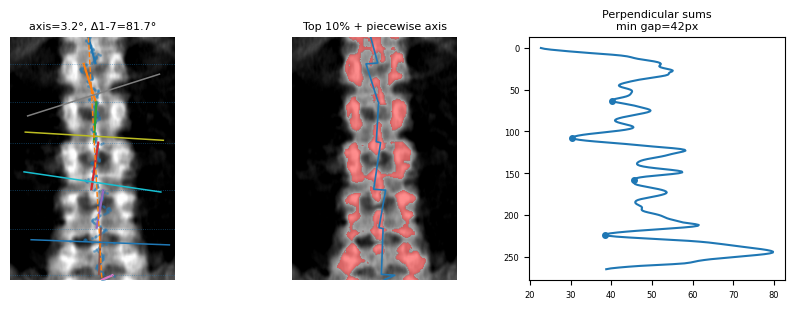

alignment_ok: True
scoliosis_proxy_deg: 81.73196804770878


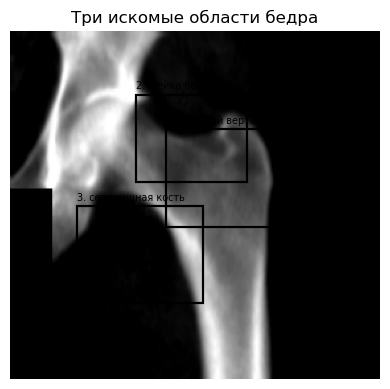

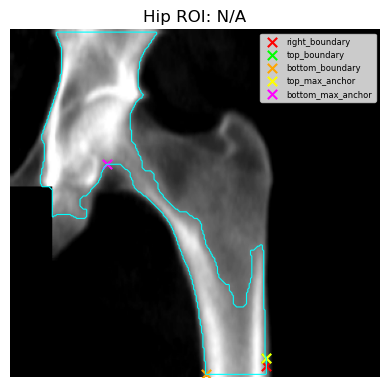

pixel_spacing_available         False
right_boundary             (193, 254)
top_max_anchor             (193, 248)
top_boundary               (193, 248)
bottom_max_anchor           (73, 101)
bottom_boundary            (148, 260)
top_margin_mm                     NaN
bottom_margin_mm                  NaN
right_margin_mm                   NaN
top_margin_ok                    None
bottom_margin_ok                 None
right_margin_ok                  None
hip_roi_ok                       None
Name: value, dtype: object

In [14]:
def first_path(mask,description):
    paths=labels_df.loc[mask,"dicom_path"]
    if len(paths): return paths.iloc[0]
    print(f"Нет размеченного изображения для: {description}"); return None

spine_demo_path=first_path(labels_df["label"].eq("SPINE"),"SPINE")
left_leg_path=first_path(labels_df["anatomy3"].eq("LEG_LEFT"),"LEG_LEFT")
if left_leg_path is None:
    left_leg_path=first_path(labels_df["label"].eq("LEG"),"LEG")

RUN_TRAIN_ANATOMY=False
RUN_TRAIN_METAL=False
RUN_SPINE_GEOMETRY_DEMO=True
RUN_SAM_COVERAGE_DEMO=False
RUN_HIP_REGIONS_DEMO=True
RUN_INTERACTIVE_HIP_WIDTHS=False
RUN_HIP_ROI_DEMO=True

anatomy_model=metal_model=None

if RUN_TRAIN_ANATOMY:
    anatomy_model,anatomy_history,anatomy_val_outputs,anatomy_train_df,anatomy_val_df=train_anatomy_router()
    display(anatomy_history)

if RUN_TRAIN_METAL:
    metal_model,metal_history,metal_val_outputs,metal_train_df,metal_val_df=train_metal_head()
    display(metal_history)
    y_true,y_pred,y_prob=metal_val_outputs
    display(pd.DataFrame([binary_classification_metrics(y_true,y_prob)]))
    display(bootstrap_binary_ci(y_true,y_prob))
    print(classification_report(y_true,y_pred,target_names=["NO_METAL","METAL"],zero_division=0))
    print(confusion_matrix(y_true,y_pred))

if RUN_SPINE_GEOMETRY_DEMO and spine_demo_path is not None:
    spine_result=analyze_spine_geometry(spine_demo_path,show=True)
    print("alignment_ok:",abs(spine_result["spine_axis_angle_deg"])<=SPINE_MAX_TILT_DEG)
    print("scoliosis_proxy_deg:",spine_result["scoliosis_proxy_deg"])

if RUN_SAM_COVERAGE_DEMO and spine_demo_path is not None:
    display(evaluate_spine_coverage(spine_demo_path,show=True))

if RUN_HIP_REGIONS_DEMO and left_leg_path is not None:
    show_hip_regions(left_leg_path,side="LEFT")

if RUN_INTERACTIVE_HIP_WIDTHS and left_leg_path is not None:
    hip_points=select_points(left_leg_path)
    show_hip_regions(left_leg_path,side="LEFT",points=hip_points)
    display(analyze_hip_position(left_leg_path,hip_points))

if RUN_HIP_ROI_DEMO and left_leg_path is not None:
    display(pd.Series(evaluate_hip_roi(left_leg_path,show=True),name="value"))


## 13. Использование `разметка.csv` для выбора демонстрационных случаев

In [15]:
def studies_with_task_value(task, value="1"):
    if task not in task_labels.columns:
        return []
    values = task_labels[task].astype(str).str.strip()
    return task_labels.loc[values.eq(str(value)), "study"].tolist()


def scoliosis_studies():
    if "scoliosis_from_comment" not in task_labels.columns:
        return []
    return task_labels.loc[task_labels["scoliosis_from_comment"].eq(1), "study"].tolist()


print("Строк в task_labels:", len(task_labels))

if task_labels.empty:
    print(
        "task_labels пуст. Проверь предыдущую ячейку: "
        "какой файл разметки найден и распознаны ли study UID."
    )
else:
    checks = {
        "spine_alignment=1": studies_with_task_value("spine_alignment", "1"),
        "scoliosis in comment": scoliosis_studies(),
        "right hip position/rotation=1": studies_with_task_value("right_hip_position_rotation", "1"),
        "left hip position/rotation=1": studies_with_task_value("left_hip_position_rotation", "1"),
    }
    for name, studies in checks.items():
        print(f"{name}: n={len(studies)}, examples={studies[:10]}")

Строк в task_labels: 100
spine_alignment=1: n=10, examples=['2.25.309085571913348252136520206003694446566', '2.25.37515662379281069436632838996073181551', '2.25.39068163399801173920284179500049527111', '2.25.73070100851377917031356937075051545239', '2.25.102755089973625799055786462646268820450', '2.25.127126130998341190348103034690069487890', '2.25.173753313169335820519632380691065649420', '2.25.220866240977467582196609708837940253840', '2.25.269648774413746842548908998641183395622', '2.25.190331309633057244929837507901317950031']
scoliosis in comment: n=14, examples=['2.25.338439598607961312040815816824093323492', '2.25.339027809107632348165171236474821772940', '2.25.52532476139575422857225834315571570912', '2.25.112621744005021908434051268014787122937', '2.25.269742577365511543488820993979123763373', '2.25.276415754443998872860614500027519740375', '2.25.286999464611662854355201599068538813496', '2.25.322202456901330781765399791024580391565', '2.25.102965897799404973225419898683246248

## Итоговая структура

- `load_labels()` читает DICOM metadata и формирует patient-level group.
- `train_anatomy_router()` обучает `SPINE / LEG_LEFT / LEG_RIGHT` без leakage.
- `train_metal_head()` обучает supervised binary head для металла.
- `show_hip_regions()` показывает три искомые области без поиска горбика.
- `analyze_hip_position()` отмечает точки найденной минимальной ширины.
- `evaluate_hip_roi()` реализует согласованную геометрию границ и критерии 3/3/2 см.
- `evaluate_spine_coverage()` отдельно оценивает половину T12 и подвздошные кости; площадь и верхняя точка сохраняются для сравнения.
- `analyze_spine_geometry()` сохраняет угол оси и исследовательский `scoliosis_proxy`.
- `run_qc_image()` / `run_batch_qc()` формируют устойчивый структурированный результат.
